In [1]:
import Meshes as Meshes
using CairoMakie: CairoMakie as Makie
using Unitful: m, ustrip, Length
using LinearAlgebra: cross, dot, norm
using MarineHydro
using DifferentiationInterface 
import ForwardDiff 

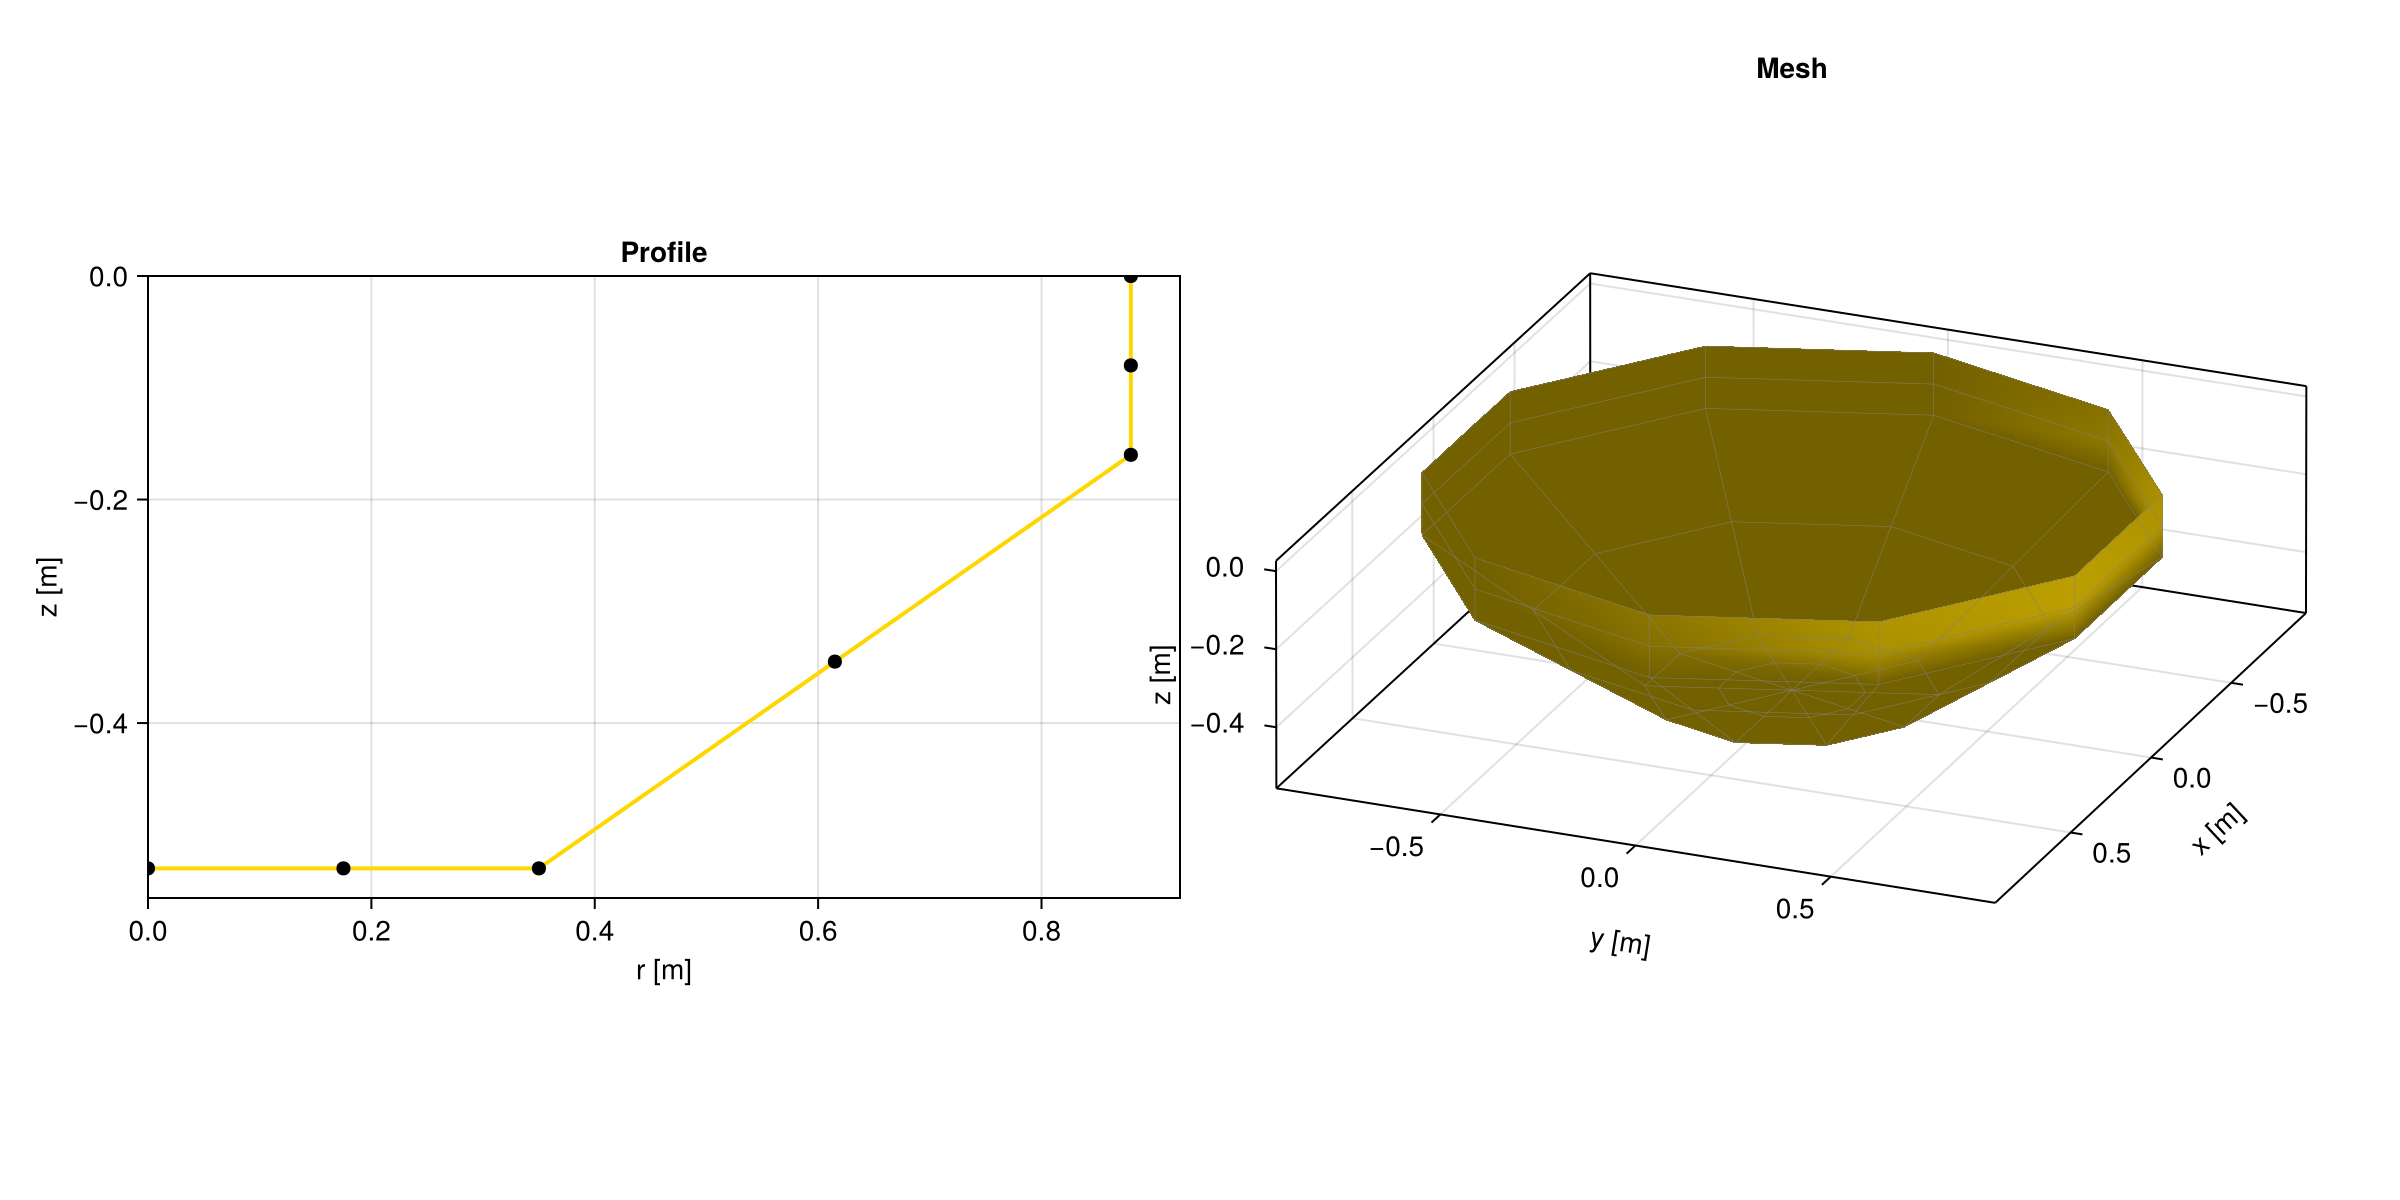

Mesh([0.88 0.0 -0.0; 0.7119349550499537 0.5172510220173764 -0.0; … ; 0.14157797401561578 -0.10286241915118283 -0.53; 0.0 0.0 -0.53], [0 10 11 1; 1 11 12 2; … ; 58 60 59 59; 59 60 50 50], Number[0.7959674775249769 0.2586255110086882 -0.04; 0.49193495504995377 0.6770903781785558 -0.04000000000000001; … ; 0.06521864934374384 -0.08976576983427824 -0.53; 0.10552599133853859 -0.03428747305039428 -0.53], Number[0.9510565162951536 0.3090169943749474 0.0; 0.587785252292473 0.8090169943749473 0.0; … ; 0.0 0.0 -1.0; 0.0 0.0 -1.0], [0.043509592807992596, 0.0435095928079926, 0.04350959280799259, 0.04350959280799259, 0.0435095928079926, 0.043509592807992596, 0.043509592807992596, 0.04350959280799259, 0.04350959280799259, 0.04350959280799262  …  0.009000461675728494, 0.009000461675728492, 0.009000461675728492, 0.009000461675728494, 0.009000461675728494, 0.009000461675728494, 0.009000461675728492, 0.009000461675728492, 0.009000461675728495, 0.009000461675728497], Number[0.2748610917864156, 0.274861091

In [2]:
r1 = 0.88
r2 = 0.35
d1 = 0.16
d2 = 0.37
n_points = (3, 3, 3)
n_theta = 10
show_plot = true


mhmesh = wavebot_mesh(r1,r2,d1,d2,n_points,n_theta,show_plot)

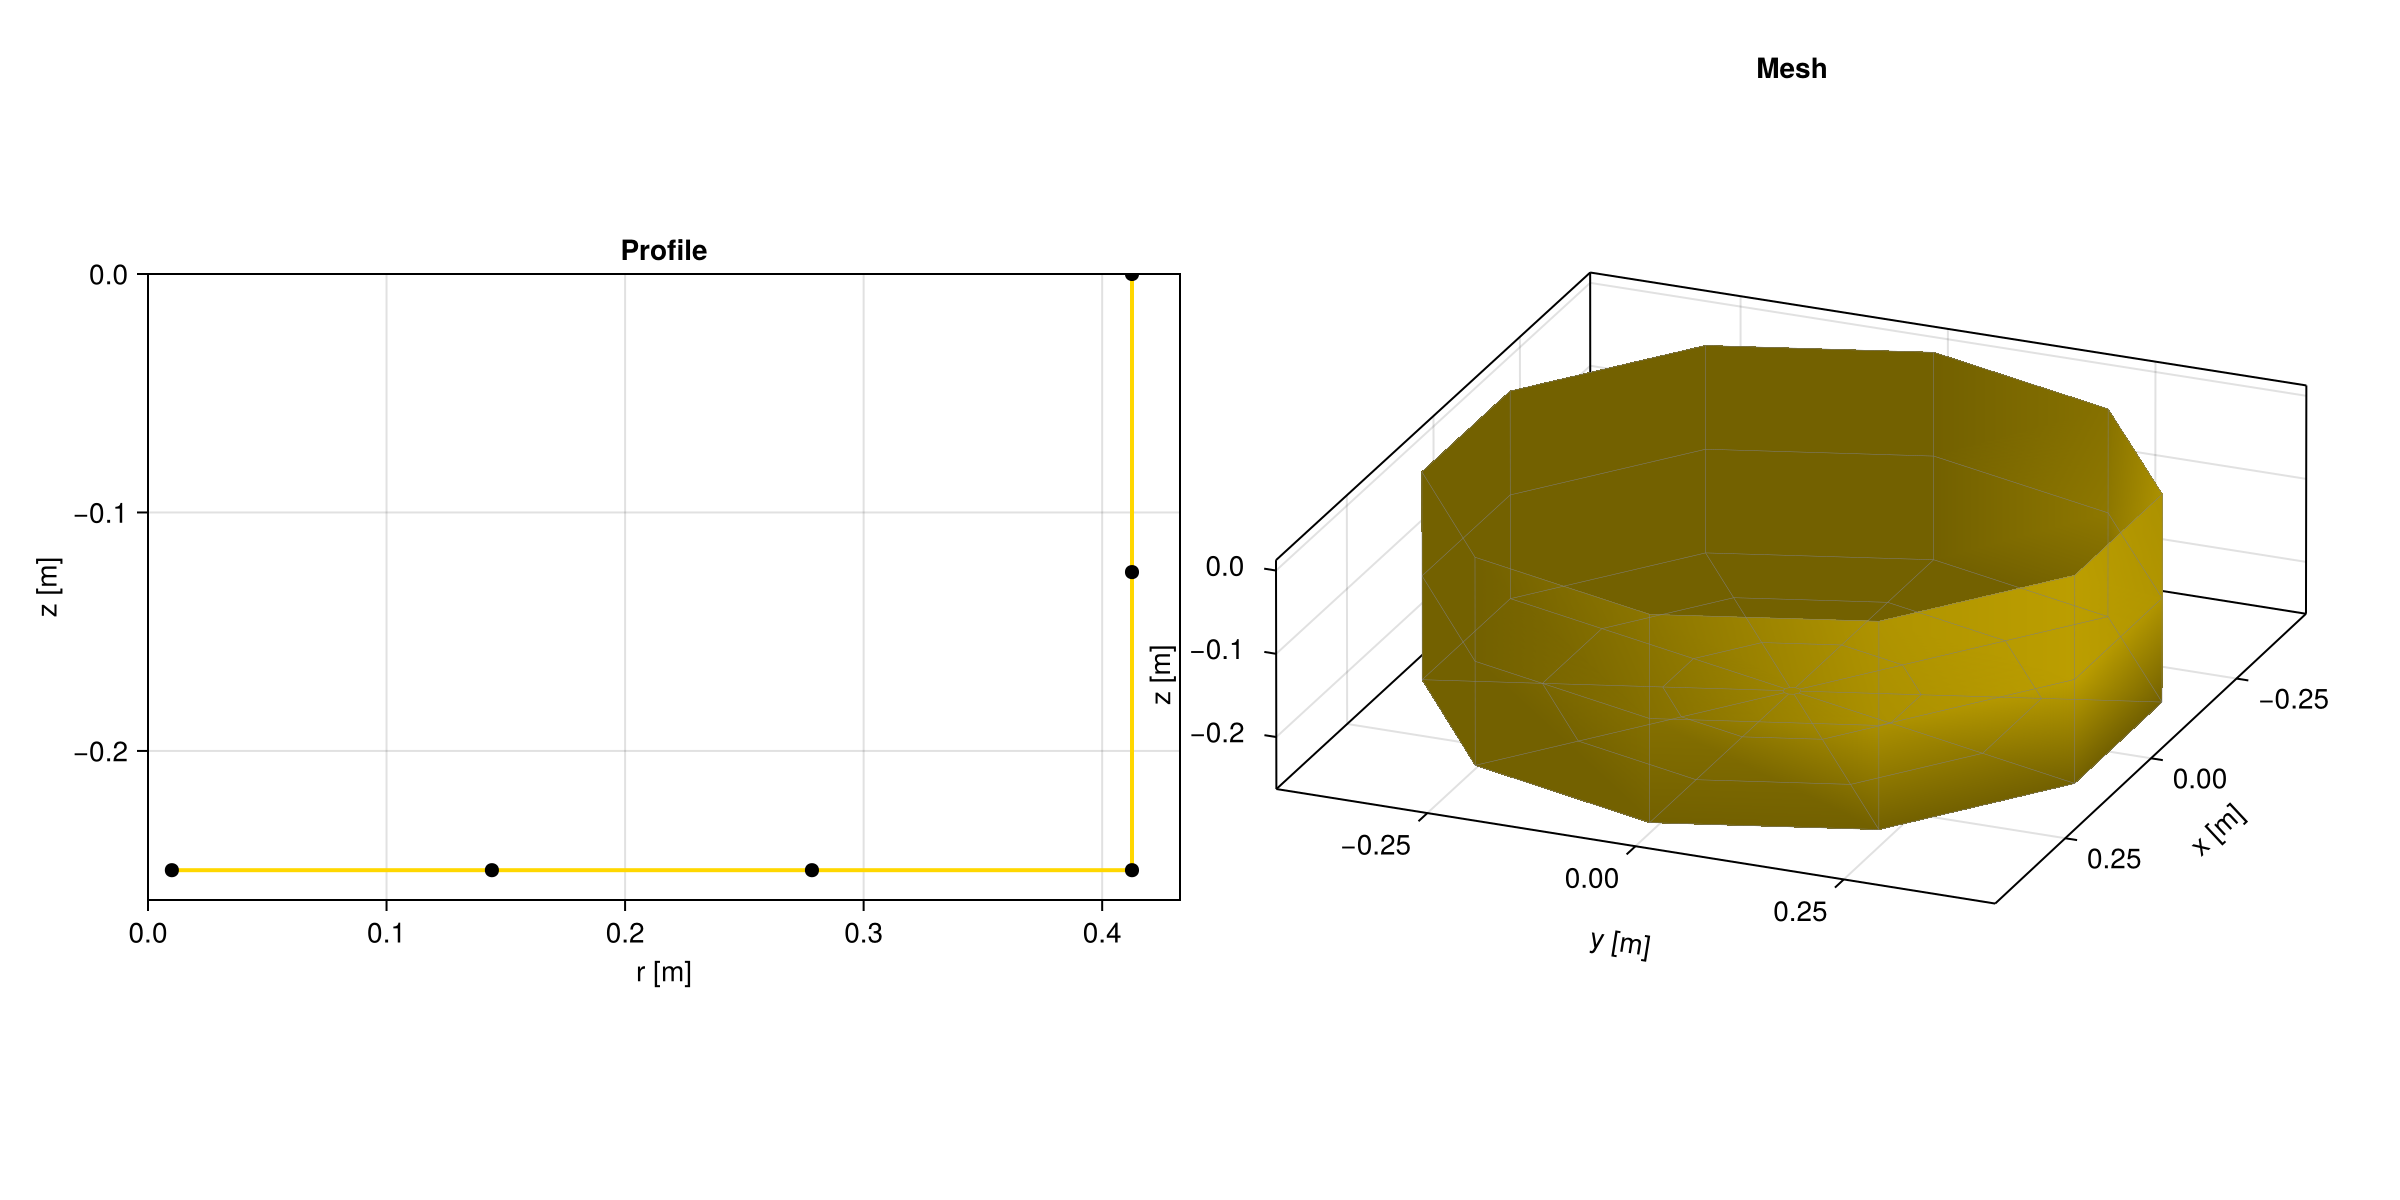

Mesh([0.41250000000000003 0.0 0.0; 0.33371951017966583 0.24246141657064518 0.0; … ; 0.0030901699437494725 -0.009510565162951536 -0.25; 0.008090169943749474 -0.005877852522924734 -0.25], [0 10 11 1; 1 11 12 2; … ; 48 58 59 49; 49 59 50 40], Number[0.37310975508983296 0.12123070828532258 -0.0625; 0.23059451017966584 0.31738611477119805 -0.0625; … ; 0.05396948153801857 -0.07428261864613157 -0.25; 0.08732445548372399 -0.028373435549475568 -0.25], Number[0.9510565162951536 0.30901699437494745 0.0; 0.5877852522924731 0.8090169943749476 0.0; … ; 0.0 0.0 -1.0; 0.0 0.0 -1.0], [0.031867377544916455, 0.03186737754491645, 0.031867377544916455, 0.03186737754491645, 0.031867377544916455, 0.03186737754491646, 0.03186737754491645, 0.03186737754491645, 0.031867377544916455, 0.03186737754491647  …  0.006078883242892817, 0.006078883242892817, 0.0060788832428928154, 0.006078883242892817, 0.006078883242892817, 0.006078883242892816, 0.006078883242892817, 0.0060788832428928154, 0.006078883242892814, 0.006078

In [3]:
radii_upper = 1.0
radii_lower = 0.1
draft_upper = 2.0
draft_lower = 0.25



r_initial = 0.5
n_side = 4-1 # number of design vars-1 (draft is also a design var)

# inputs
# r_side = ones(n_side) * r_initial
# r_side = collect(range(0.5, 0.1, length=n_side)) # last radius cannot be zero
draft = draft_lower
# draft = draft_upper
# r_side = ones(n_side) * radii_upper
r_side = ones(n_side) * (radii_upper+radii_lower)/2 * 0.75
# rad_ref = (radii_upper+radii_lower)/2 * 0.75
# r_side = collect(range(rad_ref*1.1, rad_ref*0.9, length=n_side))
x_val = vcat(r_side,draft)

# r_side = ones(n_side) * (radii_upper+radii_lower)/2 
# draft_nom = (draft_lower+draft_upper)/2
# x_val = vcat(r_side,draft)




function arbitrary_axisymmetric_mesh(x::Vector, show_plot)

    r_side = x[1:end-1]
    draft = x[end]
    n_side = length(r_side)

    z_side = collect(range(-0.0, -draft, length=n_side))

    panel_z_len = abs(z_side[1]-z_side[2])
    last_z = z_side[end]

    n_bottom = 3

    z_bottom = ones(n_bottom) * (-draft)
    r_bottom = collect(range(r_side[end], 0.01, length=n_bottom+1))[2:end]

    z_vals = vcat(z_side, z_bottom)
    r_vals = vcat(r_side, r_bottom)

    n_theta = 10

    MH_mesh = axisymmetric_mesh(r_vals,z_vals,n_theta,show_plot)

    return MH_mesh
end

arbitrary_axisymmetric_mesh(x::Vector) = arbitrary_axisymmetric_mesh(x, false)

arbitrary_axisymmetric_mesh(x_val, true)

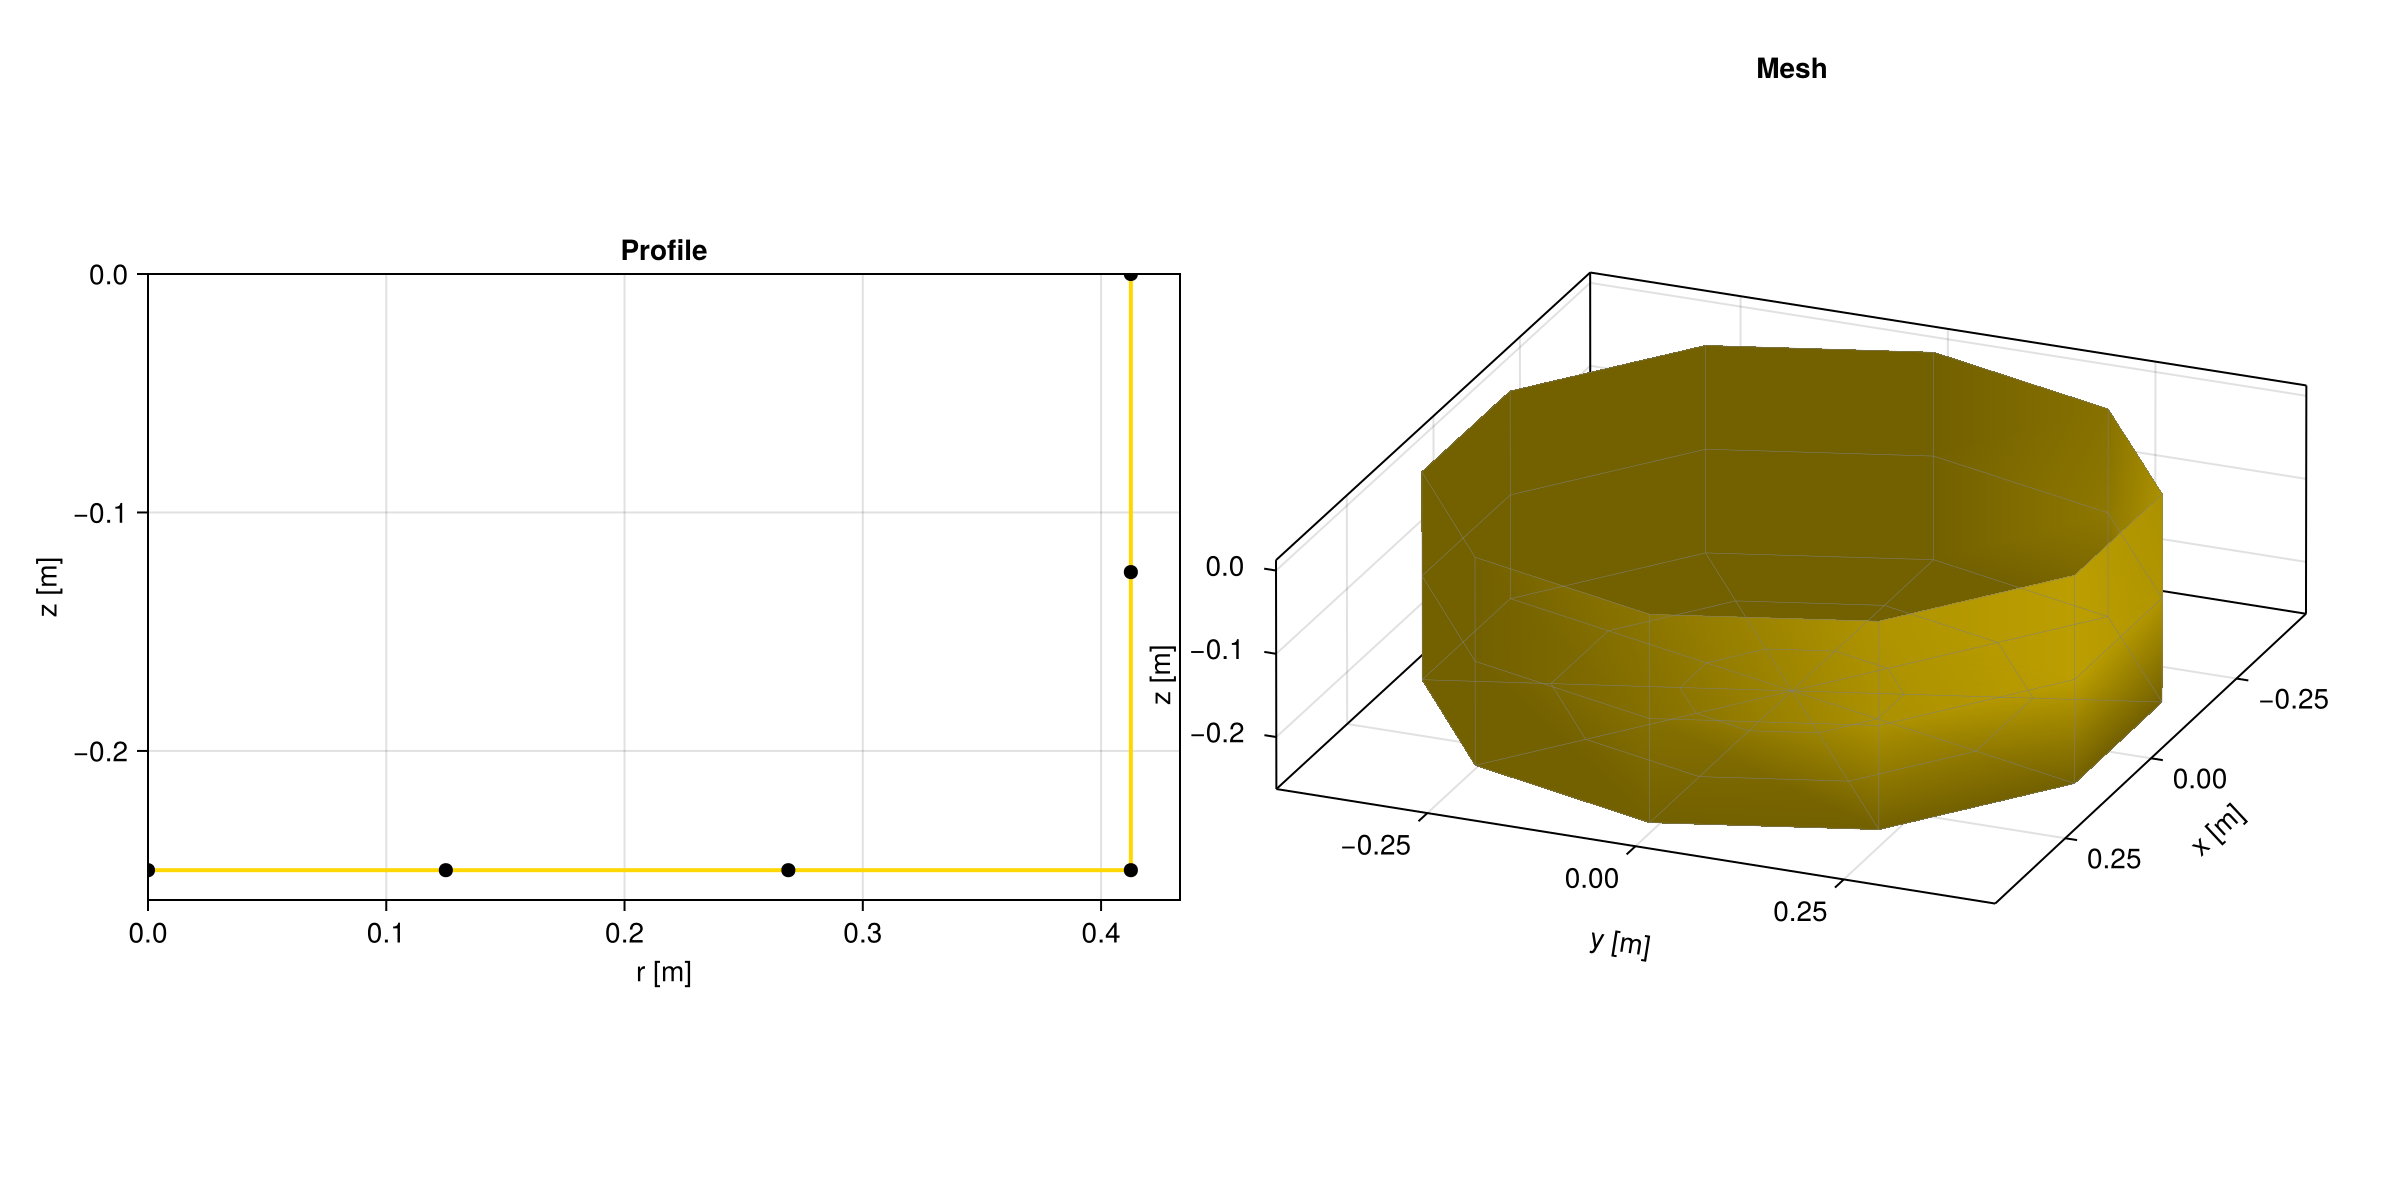

Mesh([0.41250000000000003 0.0 -0.0; 0.33371951017966583 0.24246141657064518 -0.0; … ; 0.10112712429686842 -0.07347315653655917 -0.25; 0.0 0.0 -0.25], [0 10 11 1; 1 11 12 2; … ; 48 50 49 49; 49 50 40 40], Number[0.37310975508983296 0.12123070828532258 -0.0625; 0.23059451017966584 0.31738611477119805 -0.0625; … ; 0.046584749531245605 -0.06411840702448446 -0.25; 0.07537570809895615 -0.024491052178853057 -0.25], Number[0.9510565162951536 0.30901699437494745 0.0; 0.5877852522924731 0.8090169943749476 0.0; … ; 0.0 0.0 -1.0; 0.0 0.0 -1.0], [0.031867377544916455, 0.03186737754491645, 0.031867377544916455, 0.03186737754491645, 0.031867377544916455, 0.03186737754491646, 0.03186737754491645, 0.03186737754491645, 0.031867377544916455, 0.03186737754491647  …  0.004592072283534946, 0.004592072283534946, 0.0045920722835349455, 0.004592072283534946, 0.004592072283534946, 0.004592072283534946, 0.004592072283534946, 0.0045920722835349455, 0.004592072283534946, 0.004592072283534948], Number[0.14196734140

In [4]:
r1 = r_side[1]
r2 = 0.125
d1 = draft
d2 = 0.0
n_points = (2, 3, 3)
n_theta = 10
show_plot = true


mhmesh = wavebot_mesh(r1,r2,d1,d2,n_points,n_theta,show_plot)

In [5]:
function wb_mesh(x)
    r1=x[1]
    r2=x[2]
    d1=x[3]
    d2=x[4]
    n_points=(3, 3, 3)
    n_theta = 10
    show_plot = false
    return wavebot_mesh(r1,r2,d1,d2,n_points,n_theta,show_plot)
end
x_wb = [r1,r2,d1,d2]
wb_mesh(x_wb)

Mesh([0.41250000000000003 0.0 -0.0; 0.33371951017966583 0.24246141657064518 -0.0; … ; 0.05056356214843421 -0.036736578268279585 -0.25; 0.0 0.0 -0.25], [0 10 11 1; 1 11 12 2; … ; 58 60 59 59; 59 60 50 50], Number[0.37310975508983296 0.12123070828532258 -0.0625; 0.23059451017966584 0.31738611477119805 -0.0625; … ; 0.023292374765622802 -0.03205920351224223 -0.25; 0.037687854049478074 -0.012245526089426528 -0.25], Number[0.9510565162951536 0.30901699437494745 0.0; 0.5877852522924731 0.8090169943749476 0.0; … ; 0.0 0.0 -1.0; 0.0 0.0 -1.0], [0.031867377544916455, 0.03186737754491645, 0.031867377544916455, 0.03186737754491645, 0.031867377544916455, 0.03186737754491646, 0.03186737754491645, 0.03186737754491645, 0.031867377544916455, 0.03186737754491647  …  0.0011480180708837366, 0.0011480180708837366, 0.0011480180708837364, 0.0011480180708837366, 0.0011480180708837366, 0.0011480180708837366, 0.0011480180708837366, 0.0011480180708837364, 0.0011480180708837366, 0.001148018070883737], Number[0.14

In [6]:
MH_mesh = arbitrary_axisymmetric_mesh(x_val)

Mesh([0.41250000000000003 0.0 0.0; 0.33371951017966583 0.24246141657064518 0.0; … ; 0.0030901699437494725 -0.009510565162951536 -0.25; 0.008090169943749474 -0.005877852522924734 -0.25], [0 10 11 1; 1 11 12 2; … ; 48 58 59 49; 49 59 50 40], Number[0.37310975508983296 0.12123070828532258 -0.0625; 0.23059451017966584 0.31738611477119805 -0.0625; … ; 0.05396948153801857 -0.07428261864613157 -0.25; 0.08732445548372399 -0.028373435549475568 -0.25], Number[0.9510565162951536 0.30901699437494745 0.0; 0.5877852522924731 0.8090169943749476 0.0; … ; 0.0 0.0 -1.0; 0.0 0.0 -1.0], [0.031867377544916455, 0.03186737754491645, 0.031867377544916455, 0.03186737754491645, 0.031867377544916455, 0.03186737754491646, 0.03186737754491645, 0.03186737754491645, 0.031867377544916455, 0.03186737754491647  …  0.006078883242892817, 0.006078883242892817, 0.0060788832428928154, 0.006078883242892817, 0.006078883242892817, 0.006078883242892816, 0.006078883242892817, 0.0060788832428928154, 0.006078883242892814, 0.006078

In [7]:
backend = AutoForwardDiff()

function surface_area(x)
    MH_mesh = arbitrary_axisymmetric_mesh(x)
    return sum(MH_mesh.areas)
end

function compute_SA_and_gradient(x_val)
    return value_and_gradient(x -> surface_area(x), backend, x_val)
end

compute_SA_and_gradient (generic function with 1 method)

In [8]:
# compute_SA_and_gradient(x_val)

In [9]:
theoretical_SA = pi * r_initial * sqrt(draft^2 + r_initial^2)

0.8781018413800908

In [10]:
function hydrostatic_program(x)
    r_side = x[1:end-1]
    draft = x[end]
    n_side = length(r_side)
    
    z_side = range(-1e-3, -draft, length=n_side)

    rho_w = 1025.0 
    g = 9.81 
    K = rho_w * g * pi * r_side[1]^2 


    volume = 0.0
    for i in 1:(n_side-1)
        h_mid = abs(z_side[i] - z_side[i+1])
        r1 = r_side[i]
        r2 = r_side[i+1]

        volume += (pi * h_mid / 3) * (r1^2 + r1 * r2 + r2^2)
    end
    
    M = rho_w * volume 

    return [M, K]
end

hydrostatic_program (generic function with 1 method)

In [11]:


# Hydrostatics
function hydrostatic_program(x)
    r_side = x[1:end-1]
    draft = x[end]
    n_side = length(r_side)
    
    z_side = range(-1e-3, -draft, length=n_side)

    rho_w = 1025.0 
    g = 9.81 
    K = rho_w * g * pi * r_side[1]^2 


    volume = 0.0
    for i in 1:(n_side-1)
        h_mid = abs(z_side[i] - z_side[i+1])
        r1 = r_side[i]
        r2 = r_side[i+1]

        volume += (pi * h_mid / 3) * (r1^2 + r1 * r2 + r2^2)
    end
    
    M = rho_w * volume 

    return [M, K]
end

# Radiation
function radiation_program(mesh, omega, dof) 
    A, B = calculate_radiation_forces(mesh,dof,omega)
    # display("Damping: $B")
    return [A, B]
end

# Diffraction
function diffraction_program(mesh, omega, dof) 
    F_D = DiffractionForce(mesh,omega,dof)
    return [real(F_D),imag(F_D)]
end

function incident_program(mesh, omega, dof) 
    F_FK = FroudeKrylovForce(mesh,omega,dof)
    return [real(F_FK),imag(F_FK)]
end

# Everything
dof = [0.0,0.0,1.0]

function compute_for_omega(mesh, omega)

    # M, K = hydrostatic_program(r1, r2, d1, d2)
    A, B = radiation_program(mesh, omega, dof)
    F_D_real, F_D_imag = diffraction_program(mesh, omega, dof) 
    F_FK_real, F_FK_imag = incident_program(mesh, omega, dof)
    # add negatives to imag since wot uses +i omega t instead of -i omega t
    return [A, B, F_D_real, -F_D_imag, F_FK_real, -F_FK_imag]
end

backend = AutoForwardDiff()


function arbitrary_axisymmetric_mesh(x, show_plot)

    r_side = x[1:end-1]
    draft = x[end]
    n_side = length(r_side)

    z_side = collect(range(-1e-3, -draft, length=n_side))

    panel_z_len = abs(z_side[1]-z_side[2])
    last_z = z_side[end]

    n_bottom = 3

    z_bottom = ones(n_bottom) * (-draft)
    r_bottom = collect(range(r_side[end], 0.0, length=n_bottom+1))[2:end]

    z_vals = vcat(z_side, z_bottom)
    r_vals = vcat(r_side, r_bottom)

    n_theta = 10

    MH_mesh = axisymmetric_mesh(r_vals,z_vals,n_theta,show_plot)

    return MH_mesh
end

arbitrary_axisymmetric_mesh(x) = arbitrary_axisymmetric_mesh(x, false)


function compute_vals(x, omegas)
    set_rho!(1025.0)
    x=vec(x)
    mesh = arbitrary_axisymmetric_mesh(x)    
    M_val, K_val = hydrostatic_program(x)
    results_per_omega = [compute_for_omega(mesh, omega) for omega in omegas]
    vec_reduced = reduce(vcat, results_per_omega)
    
    return [M_val; K_val; vec_reduced]
end

function compute_all(x_val, omegas)
    return value_and_jacobian(x -> compute_vals(x, omegas), backend, x_val)
end


function surface_area(x)
    MH_mesh = arbitrary_axisymmetric_mesh(x)
    return sum(MH_mesh.areas)
end


function centers(x)
    MH_mesh = arbitrary_axisymmetric_mesh(x)
    return sum(abs.(MH_mesh.centers[:,1]))
end

function compute_SA_and_gradient(x_val)
    return value_and_gradient(x -> surface_area(x), backend, x_val)
end

compute_SA_and_gradient (generic function with 1 method)

In [12]:
2*pi*0.3

1.8849555921538759

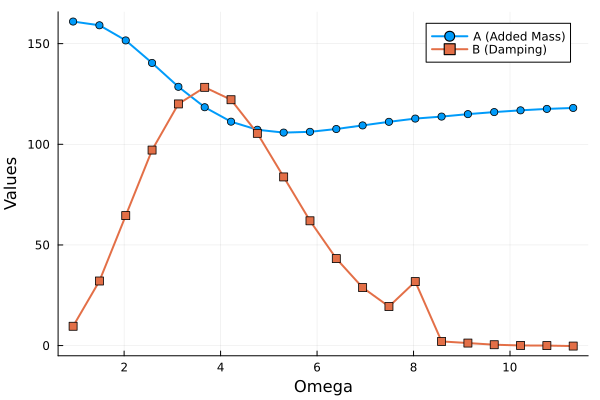

In [13]:
using Plots

omega = 2*pi*0.3


num_omegas = 20
omegas = collect(range(omega/2,6*omega,length=num_omegas))
dof = [0.0,0.0,1.0]

A = zeros(num_omegas)
B = zeros(num_omegas)

for i in 1:num_omegas
    omega = omegas[i]    
    A[i], B[i] = radiation_program(mhmesh, omega, dof)
end

plot(omegas, A, label="A (Added Mass)", xlabel="Omega", ylabel="Values", linewidth=2, marker=:circle)
plot!(omegas, B, label="B (Damping)", linewidth=2, marker=:square)    

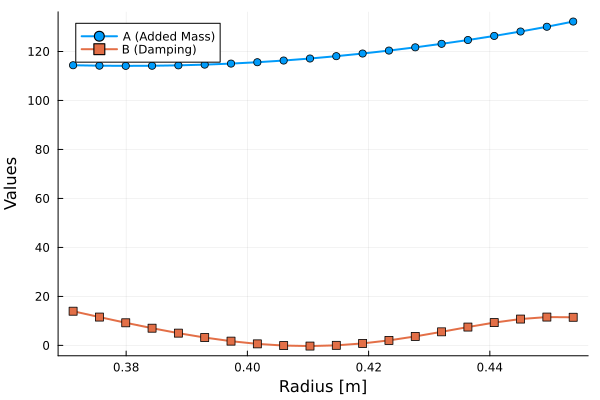

In [14]:
rad = (radii_upper+radii_lower)/2 * 0.75
r_side = ones(n_side) * (radii_upper+radii_lower)/2 * 0.75

num_r = 20
r_vals = collect(range(0.9*rad,1.1*rad,length=num_r))
# d_vals = collect(range(0.9*draft_lower,1.1*draft_lower,length=num_r))
dof = [0.0,0.0,1.0]



A = zeros(num_r)
B = zeros(num_r)

for i in 1:num_r  
    # draft = d_vals[i]
    r_side[2] = r_vals[i]
    x_new = vcat(r_side,draft) 
    new_mesh = arbitrary_axisymmetric_mesh(x_new)
    A[i], B[i] = radiation_program(new_mesh, omega, dof)
end

plot(r_vals, A, label="A (Added Mass)", xlabel="Radius [m]", ylabel="Values", linewidth=2, marker=:circle)
plot!(r_vals, B, label="B (Damping)", linewidth=2, marker=:square)  

In [15]:
B

20-element Vector{Float64}:
 13.947424323465025
 11.560911304724552
  9.235908269208243
  7.027454924786809
  4.996240844047338
  3.2069477147773555
  1.7256753759104313
  0.6132316401436313
 -0.06637126924629526
 -0.2730882120544326
  0.01733246669162407
  0.8021287232892454
  2.04355633663712
  3.6628495041396367
  5.535481018681281
  7.490248492989887
  9.312091782332363
 10.759878821632174
 11.560734790823595
 11.474185730280151

In [16]:
all_out = compute_all(x_val, [omega, 2*omega])

([136.43349073102559, 5375.150779403056, 120.52663886491479, -0.19532659005554584, 58.39460402058344, -4.193771331776089, -30.783439676823946, 1.8207657603852567e-14, 119.99698380888039, 0.05146855330150407, -5.128279258134551, -0.23639504942095915, -0.001262336863340917, 4.2825985813177425e-18], [165.37392815881884 330.7478563176377 165.37392815881884 547.9256655864481; 26061.337112257235 0.0 0.0 0.0; … ; 815.4422928172096 -814.2398454625511 -1.070202310319744 0.06583714592809166; -4.973799150320701e-14 4.9654724776360126e-14 1.0299920638612292e-17 -2.0729945537922845e-16])

In [17]:
all_out[2]

14×4 Matrix{Float64}:
   165.374         330.748          165.374        547.926
 26061.3             0.0              0.0            0.0
   -56.1147        152.061          745.505         72.0302
   -87.4172         46.8815           5.90331        9.71497
  -734.717        8315.5          -7777.26         -12.3655
 -2784.7          2124.01           159.862        290.258
 -1463.49         1176.7            123.019        401.377
     9.09495e-13    -7.67386e-13     -1.03029e-13   -2.52243e-13
    28.1036         92.1032         717.149         60.2661
    -9.61308        27.5148          -4.73003       -0.796789
 -1067.78          -97.2079          47.2702        53.0598
   -17.5355        -25.6052          -0.286299       7.72612
   815.442        -814.24            -1.0702         0.0658371
    -4.9738e-14      4.96547e-14      1.02999e-17   -2.07299e-16

In [18]:
using FiniteDifferences
method = central_fdm(5, 1)
J = FiniteDifferences.jacobian(method, x -> compute_vals(x, [omega, 2*omega]), x_val)[1]


14×4 Matrix{Float64}:
   165.374         330.748         165.374        547.926
 26061.3            -1.05826e-9     -1.55019e-9    -6.93693e-10
   -55.703         225.55          671.605         72.0302
  -122.12           68.5775         18.9104         9.71497
  -941.935         884.847        -139.371        -12.3655
 -3092.26         2117.43          474.013        290.258
 -1463.49         1176.7           123.019        401.377
     2.42531e-11    -9.92118e-11    -2.34143e-10   -3.16136e-11
    34.6116        171.055         631.689         60.2661
   -11.5846         25.5441         -0.787805      -0.796789
 -1095.15          -94.8301         72.2583        53.0598
   -15.2466        -26.1522         -2.02815        7.72612
   815.442        -814.24           -1.0702         0.0658371
     1.1264e-11      6.2687e-12      4.97103e-14    3.16996e-15

In [19]:
# J

In [20]:
SA_grad = value_and_gradient(x -> surface_area(x), backend, x_val)

(1.1371303299491393, [0.3862712429686843, 0.7725424859373686, 2.810885408675136, 2.5493902035933163])

In [21]:
SA_grad[2]

4-element Vector{Float64}:
 0.3862712429686843
 0.7725424859373686
 2.810885408675136
 2.5493902035933163

In [22]:
using FiniteDifferences
method = central_fdm(5, 1)
J = FiniteDifferences.grad(method, x -> surface_area(x), x_val)[1]


4-element Vector{Float64}:
 0.3862712429701666
 0.772542485937465
 2.8108854086763118
 2.549390203593283

In [23]:
centers(x_val)
centers_grad = value_and_gradient(x -> centers(x), backend, x_val)
centers_grad[2]

4-element Vector{Float64}:
  2.9270509831248424
  5.854101966249683
 12.201115728996184
 -1.5543122344752192e-15

In [24]:
using FiniteDifferences
method = central_fdm(5, 1)
J = FiniteDifferences.grad(method, x -> centers(x), x_val)[1]

4-element Vector{Float64}:
  2.9270509831230687
  5.854101966251497
 12.201115728997546
 -2.407286297791515e-14

In [25]:
#verify derivatives wrt omega work?
der_wrt_omega = derivative(o -> compute_for_omega(MH_mesh, o), backend, omega)

6-element Vector{Float64}:
   0.5307423658034693
  -2.0106853882494584
 -35.5570240894173
 -22.209427146985213
  16.700994647156485
  -1.2434497875801753e-14

In [26]:
method = central_fdm(5, 1)
J = FiniteDifferences.jacobian(method, o -> compute_for_omega(MH_mesh, o), omega)[1]


6×1 Matrix{Float64}:
   0.5307423708601501
  -2.0106853898839514
 -35.5570241435673
 -22.209427167903858
  16.700994647188768
   1.2820676939395269e-11

In [27]:
function wb_coeffs(x_wb,omega)
    mesh = wb_mesh(x_wb)
    return compute_for_omega(mesh, omega)
end

wb_coeffs (generic function with 1 method)

In [28]:
wb_jac = value_and_jacobian(x -> wb_coeffs(x,omega), backend, x_wb)
wb_jac[2]

6×4 Matrix{Float64}:
  847.324         -16.3139        72.5987        548.291
  -44.4163          2.78199       12.4565        -25.4876
 -163.226        -133.414        -69.7805       1679.24
 -524.545          26.1318       299.747         -80.9783
 -186.263          45.0138       416.432          -3.9029
    2.55795e-13     2.22045e-14   -3.06422e-14    -2.22045e-15

In [29]:
using FiniteDifferences
method = central_fdm(5, 1)
J = FiniteDifferences.jacobian(method, x -> wb_coeffs(x,omega), x_wb)[1]


6×4 Matrix{Float64}:
  847.324         -16.3139        72.5987      -82.0751
  -44.4163          2.78199       12.4565       -3.82522
 -163.226        -133.414        -69.7805      612.862
 -524.545          26.1318       299.747       -74.9316
 -186.263          45.0138       416.432        -3.9029
   -2.16636e-10    -3.07806e-11    8.0426e-11    5.07503e-11